In [5]:
import xarray as xr
import pandas as pd
import numpy as np
import cartopy.crs as ccrs
from cartopy.util import add_cyclic_point
import cartopy.feature as cf
import matplotlib.pyplot as plt
import matplotlib

In [6]:
# Open file for testing
file = '/glade/work/ekeefe/research_code/emmons_output_corr/f.e222.FCnudged_era5.f09.htap_hist_base.02.cam.h1.2017-02-06-00000.nc'
ds = xr.open_dataset(file)
ds.PS

<xarray.DataArray 'PS' (time: 10, lat: 192, lon: 288)> Size: 2MB
[552960 values with dtype=float32]
Coordinates:
  * time     (time) datetime64[ns] 80B 2017-02-06 2017-02-07 ... 2017-02-15
  * lat      (lat) float64 2kB -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
  * lon      (lon) float64 2kB 0.0 1.25 2.5 3.75 5.0 ... 355.0 356.2 357.5 358.8
Attributes:
    units:         Pa
    long_name:     Surface pressure
    cell_methods:  time: mean

In [137]:
# Helper functions
def inspect(ds):
    # Check that the dataset has variables necessary to compute pressure coords
    try:
        ds['P0']
        ds['hyai']
        ds['hybi']
        ds['PS']
    # If not, raise an error
    except:
        raise KeyError('This dataset does not have all components needed to handle the pressure coordinates')
        
    return None

def written_month(num):
    month_dict={'January':'01', 'February':'02', 'March':'03', 'April':'04', 'May':'05', 'June':'06', 'July':'07', 'August':'08', 'September':'09', 'October':'10', 'November':'11', 'December':'12'}
    if str(num) in month_dict.values():
        mth = [key for key,val in month_dict.items() if val==str(num)]
    else:
        raise KeyError('Please choose a valid number corresponding to a month')
    return mth[0]

In [138]:
# Function to map ozone concentrations globally
def map_atm_ozone(ds, o_arr, level, agg_method, start, end):
    all_ozone = o_arr
    
    inspect(ds)
    p0 = ds.P0 / 100 # Convert to hPa
    ps = ds.PS / 100

    # Select timing of data and check level
    if level=='troposphere' or level=='stratosphere':
        ozone_slice = all_ozone.sel(time=slice(start, end))
    else:
        raise ValueError('Not a supported level. Please choose troposphere or stratosphere')

    # Aggregate the data based on given method
    if agg_method=='mean':
        monthly_ozone = ozone_slice.groupby('time.month').mean(dim='time')
        monthly_ps = ps.groupby('time.month').mean(dim='time')
    elif agg_method=='sum':
        monthly_ozone = ozone_slice.groupby('time.month').sum(dim='time')
        monthly_ps = ps.groupby('time.month').sum(dim='time')
    elif agg_method=='median':
        monthly_ozone = ozone_slice.groupby('time.month').median(dim='time')
        monthly_ps = ps.groupby('time.month').median(dim='time')
    else:
        raise ValueError('Not a supported aggregation method. Please choose mean, sum, or median.')

    # Handle pressure
    pres_top = xr.zeros_like(monthly_ozone)
    pres_bottom = xr.zeros_like(monthly_ozone)
    pres_top = ds.hyai*p0+ds.hybi*monthly_ps
    pres_bottom = ds.hyai.shift(ilev=-1)*p0+ds.hybi.shift(ilev=-1)*monthly_ps
    threshold = 100

    if level=='troposphere':
        pressure = pres_top.where(pres_top >= threshold, drop=False)
    else:
        pressure = pres_bottom.where(pres_bottom < threshold, drop=False)
    pres_arr=[]
    for i in range(len(pressure.values)-1):
        pres_arr.append(pressure.values[i][0][0][0])

    layer_ozone = monthly_ozone.assign_coords(lev=pres_arr)
    layer_ozone = layer_ozone.where(~np.isnan(layer_ozone.lev), drop=True)

    # Handle plotting considerations
    if max(ds.lon)>350:
        layer_ozone = layer_ozone.assign_coords(lon=(((layer_ozone.lon + 180) % 360) - 180)).sortby('lon')
    layer_ozone = layer_ozone.mean(dim=['lev','month'])

    # Create the plot
    proj = ccrs.PlateCarree()
    fig = plt.figure(figsize=(10,12))
    ax = plt.axes(projection = proj)
    ax.coastlines()
    ax.add_feature(cf.BORDERS.with_scale('50m'), edgecolor = [.3,.3,.3], linewidth = 0.5)

    ozone_cyc, lon_cyc = add_cyclic_point(layer_ozone, coord = layer_ozone.lon)
    o = ax.contourf(lon_cyc, layer_ozone.lat, ozone_cyc, transform=ccrs.PlateCarree(), cmap=matplotlib.cm.RdPu)
    cb = plt.colorbar(o, extendfrac = 'auto', shrink=0.25)

    # Plot text
    level = level.capitalize()
    if agg_method=='sum':
        method = 'Total'
    else:
        method = agg_method.capitalize()
    yr = end[:4]
    month = written_month(start[5:7])
    
    cb.set_label('Ozone Concentration (mol/mol)')
    plt.title(f'{method} Monthly Global Ozone Concentration in the {level}, {month} {yr}')

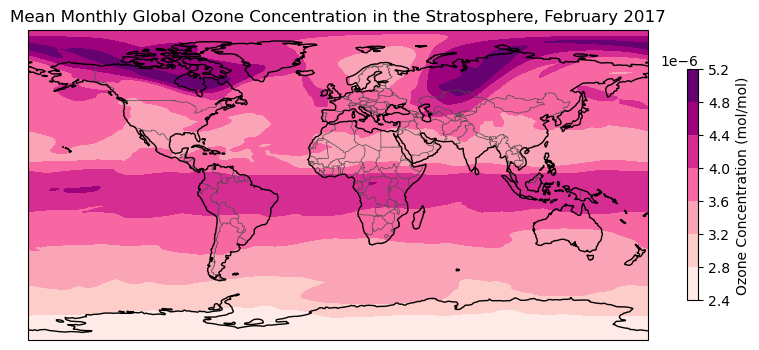

In [142]:
map_atm_ozone(ds, ds.O3, 'stratosphere', 'mean', '2017-02-10', '2017-02-11')

In [163]:
# Map surface level ozone
def map_srf_ozone(ds, o_arr, agg_method, start, end):
    ozone = o_arr
    ozone_slice = ozone.sel(time=slice(start, end))
    
    if agg_method=='mean':
        monthly_ozone = ozone_slice.groupby('time.month').mean(dim='time')
    elif agg_method=='sum':
        monthly_ozone = ozone_slice.groupby('time.month').sum(dim='time')
    elif agg_method=='median':
        monthly_ozone = ozone_slice.groupby('time.month').median(dim='time')
    else:
        raise ValueError('Not a supported aggregation method. Please choose mean, sum, or median.')

    ozone_plot = monthly_ozone.mean(dim='month')
    proj = ccrs.PlateCarree()
    fig = plt.figure(figsize=(10,12))
    ax = plt.axes(projection = proj)
    ax.coastlines()
    ax.add_feature(cf.BORDERS.with_scale('50m'), edgecolor = [.3,.3,.3], linewidth = 0.5)
    
    ozone_cyc, lon_cyc = add_cyclic_point(ozone_plot, coord = ozone_plot.lon)
    o = ax.contourf(lon_cyc, ozone_plot.lat, ozone_cyc, transform=ccrs.PlateCarree(), cmap=matplotlib.cm.YlGnBu)
    cb = plt.colorbar(o, extendfrac = 'auto', shrink=0.25)

    if agg_method=='sum':
        method = 'Total'
    else:
        method = agg_method.capitalize()
    yr = end[:4]
    month = written_month(start[5:7])
    
    cb.set_label('Ozone Concentration (mol/mol)')
    plt.title(f'{method} Monthly Surface Ozone Concentration, {month} {yr}')

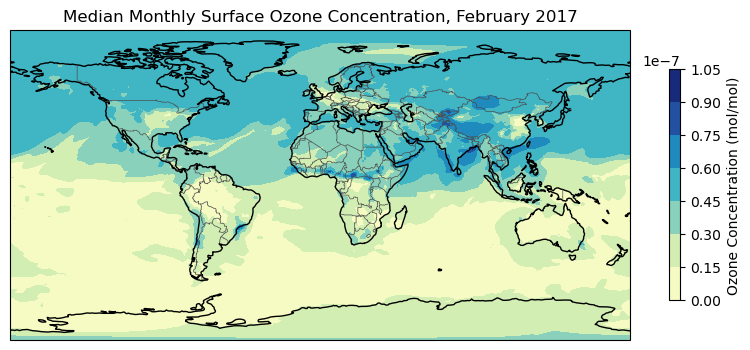

In [166]:
map_srf_ozone(ds, ds.O3_SRF, 'median', '2017-02-06', '2017-02-08')